# Principal Component Analysis (PCA) using Singular Value Decomposition (SVD)

Principal Component Analysis (PCA) is a fundamental dimensionality reduction technique widely used in data science, machine learning, and exploratory data analysis. The primary goal of PCA is to project high-dimensional data onto a lower-dimensional subspace while preserving as much variance as possible.

In this notebook, we will:
1. Explain the **mathematical relationship** between PCA and SVD.
2. Implement a custom **SVD-based PCA** class from scratch in Python.
3. **Validate** our custom implementation against scikit-learn's `PCA` module.
4. Visualize the results using high-quality plots, including a **Scree Plot**, **2D/3D projections**, **Biplot**, and **Feature Loadings Heatmap**.

We will use the **Pima Indians Diabetes Dataset** (`diabetes.csv`) for our analysis. This dataset contains 8 clinical features (e.g. Glucose levels, BMI, Blood Pressure) and a binary `Outcome` label indicating whether the patient was diagnosed with diabetes.

## Mathematical Background: Why PCA can be solved with SVD

### 1. Covariance-based PCA
Typically, PCA is defined via the covariance matrix of the centered data matrix $X_c \in \mathbb{R}^{n \times p}$ (where $n$ is the number of samples and $p$ is the number of features):

$$C = \frac{1}{n-1} X_c^T X_c$$

We find the eigenvectors $V$ and eigenvalues $\Lambda$ of the covariance matrix $C$ such that:

$$C V = V \Lambda$$

The columns of $V$ represent the principal directions (loadings), and the eigenvalues $\lambda_i$ represent the variance along each direction.

### 2. SVD of the Data Matrix
Alternatively, we can compute the **Singular Value Decomposition (SVD)** directly on the centered data matrix $X_c$:

$$X_c = U \Sigma V^T$$

where:
- $U \in \mathbb{R}^{n \times n}$ is an orthogonal matrix of left singular vectors.
- $\Sigma \in \mathbb{R}^{n \times p}$ is a diagonal matrix of singular values $s_1 \ge s_2 \ge \dots \ge s_k \ge 0$.
- $V \in \mathbb{R}^{p \times p}$ is an orthogonal matrix of right singular vectors ($V^T$ contains the vectors as rows).

### 3. Combining SVD and Covariance
Let's substitute the SVD representation into the covariance matrix equation:

$$C = \frac{1}{n-1} X_c^T X_c = \frac{1}{n-1} (U \Sigma V^T)^T (U \Sigma V^T)$$

$$C = \frac{1}{n-1} V \Sigma^T U^T U \Sigma V^T$$

Since $U$ is an orthogonal matrix ($U^T U = I$):

$$C = V \left( \frac{\Sigma^2}{n-1} \right) V^T$$

This is exactly the **spectral decomposition** of $C$! Comparing this to the covariance eigen-decomposition, we see:
1. The **right singular vectors** $V$ are the **eigenvectors** of the covariance matrix $C$ (Principal Components).
2. The **eigenvalues** $\lambda_i$ are directly related to the singular values $s_i$ by:
   $$\lambda_i = \frac{s_i^2}{n-1}$$
3. The projected coordinates (PC scores) $Z$ are obtained by:
   $$Z = X_c V = U \Sigma V^T V = U \Sigma$$

### 4. Advantages of SVD for PCA
Using SVD directly on $X_c$ is numerically more stable than explicitly computing the covariance matrix $X_c^T X_c$ (which squares the condition number of the matrix, potentially causing loss of precision on computers). SVD is therefore the standard method used in industry-grade packages like scikit-learn.

### 1. Setup and Imports
First, we import the required libraries and set up the visualization style.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configure styling for premium visuals
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 100
})
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Load and Preprocess the Dataset
We load `diabetes.csv` and standardize the features. Standardizing is crucial for PCA because it is sensitive to the scale of the features (features with large values would otherwise dominate the variance).

In [2]:
# Find dataset file
path = os.path.join('..', '..', 'Datasets', 'diabetes.csv')
if not os.path.exists(path):
    path = os.path.join('Datasets', 'diabetes.csv')

df = pd.read_csv(path)
print(f"Dataset successfully loaded from: {path}")
print(f"Data Shape: {df.shape}\n")

# Split features and target outcome
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Standardize the features (z-score scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display columns and scaled head
print("Features inside the dataset:", list(X.columns))
pd.DataFrame(X_scaled, columns=X.columns).head(3)

Dataset successfully loaded from: ..\..\Datasets\diabetes.csv
Data Shape: (768, 9)

Features inside the dataset: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584


### 3. Custom SVD-based PCA Implementation
We write a custom Python class `SVD_PCA` using standard `numpy.linalg.svd`. The class provides methods `fit`, `transform`, and `fit_transform` mimicking the scikit-learn API.

In [3]:
class SVD_PCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.singular_values_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        
    def fit(self, X):
        # Convert to numpy matrix
        X = np.array(X, dtype=np.float64)
        n_samples, n_features = X.shape
        
        # Step 1: Center the data (crucial step for SVD to align with covariance)
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        # Step 2: Singular Value Decomposition
        # X_centered = U * Sigma * Vt
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        
        # Step 3: Extract the right singular vectors (loadings/components)
        # Vt rows are the right singular vectors (V columns)
        self.components_ = Vt[:self.n_components]
        self.singular_values_ = S[:self.n_components]
        
        # Step 4: Calculate eigenvalues (explained variance of covariance)
        # eigenvalues: lambda_i = S_i^2 / (n - 1)
        all_variances = (S ** 2) / (n_samples - 1)
        self.explained_variance_ = all_variances[:self.n_components]
        
        # Step 5: Calculate explained variance ratio
        total_variance = np.sum(all_variances)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance
        
        return self
        
    def transform(self, X):
        # Center with training mean
        X = np.array(X, dtype=np.float64)
        X_centered = X - self.mean_
        
        # Step 6: Project centered data onto principal components
        # Projection Z = X_centered * V = X_centered * Vt.T
        return np.dot(X_centered, self.components_.T)
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

print("Custom SVD_PCA class implemented.")

Custom SVD_PCA class implemented.


### 4. Apply Custom SVD-PCA
We fit our custom class to project the scaled diabetes features into a 3-dimensional subspace.

In [4]:
# Initialize and run custom PCA
my_pca = SVD_PCA(n_components=3)
X_proj_custom = my_pca.fit_transform(X_scaled)
print(f"Data successfully projected from shape {X_scaled.shape} to {X_proj_custom.shape}.")

Data successfully projected from shape (768, 8) to (768, 3).


### 5. Numerical Validation against scikit-learn
We run scikit-learn's `PCA` model on the same dataset to mathematically verify our custom logic.

> [!NOTE]
> The sign of the components and projections can be flipped between implementations. This is normal because eigenvectors are defined up to sign: if $v$ is an eigenvector, $-v$ is also a valid eigenvector. We handle sign alignment during validation.

In [5]:
# Run scikit-learn PCA
sk_pca = PCA(n_components=3)
X_proj_sk = sk_pca.fit_transform(X_scaled)

# Validate explained variance and explained variance ratio
variance_match = np.allclose(my_pca.explained_variance_, sk_pca.explained_variance_)
ratio_match = np.allclose(my_pca.explained_variance_ratio_, sk_pca.explained_variance_ratio_)

# Align sign differences
sign_multipliers = []
components_match = True
projections_match = True

for i in range(3):
    # Check if component matches or matches with flipped sign
    same_sign = np.allclose(my_pca.components_[i], sk_pca.components_[i], atol=1e-7)
    opp_sign = np.allclose(my_pca.components_[i], -sk_pca.components_[i], atol=1e-7)
    
    if same_sign:
        sign_multipliers.append(1.0)
    elif opp_sign:
        sign_multipliers.append(-1.0)
    else:
        components_match = False
        
    # Check projections
    proj_same = np.allclose(X_proj_custom[:, i], X_proj_sk[:, i], atol=1e-7)
    proj_opp = np.allclose(X_proj_custom[:, i], -X_proj_sk[:, i], atol=1e-7)
    if not (proj_same or proj_opp):
        projections_match = False

print("=== MATHEMATICAL EQUIVALENCE CHECK ===")
print(f"Explained Variance matches:      {variance_match}")
print(f"Explained Variance Ratio matches:{ratio_match}")
print(f"Principal Components match:     {components_match} (accounting for sign flips)")
print(f"Projected Scores match:         {projections_match} (accounting for sign flips)")

# Align custom outputs with scikit-learn orientation for identical plotting
sign_multipliers = np.array(sign_multipliers)
X_projected_aligned = X_proj_custom * sign_multipliers
components_aligned = my_pca.components_ * sign_multipliers[:, np.newaxis]

=== MATHEMATICAL EQUIVALENCE CHECK ===
Explained Variance matches:      True
Explained Variance Ratio matches:True
Principal Components match:     True (accounting for sign flips)
Projected Scores match:         True (accounting for sign flips)


### 6. Visualizations
Now, let's create five informative visualizations of our PCA results.

#### A. Scree Plot
A scree plot shows the proportion of variance explained by each individual component, alongside the cumulative sum. It is used to decide the optimal number of components to retain.

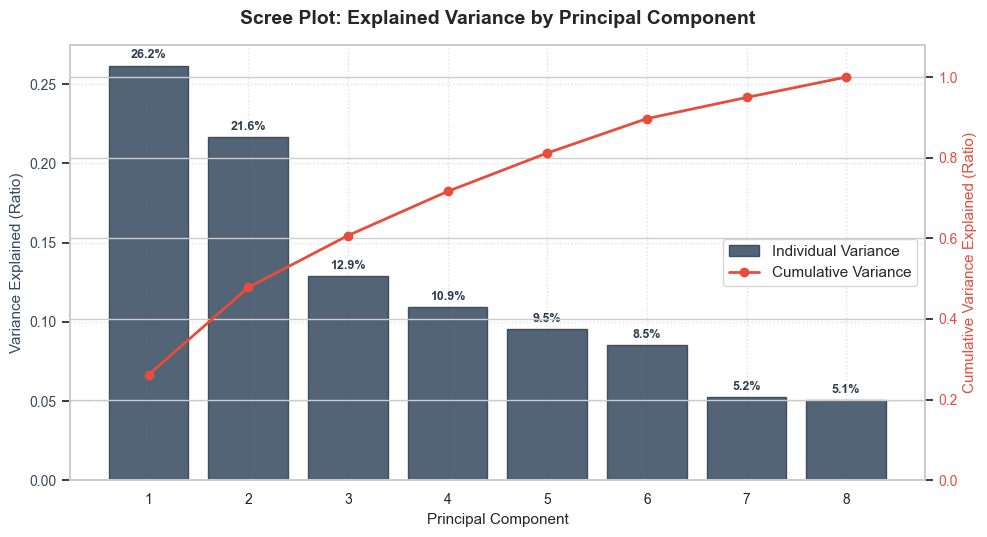

In [6]:
# Run PCA with all available features to calculate full variance profile
full_pca = SVD_PCA(n_components=X_scaled.shape[1])
full_pca.fit(X_scaled)

evr = full_pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

fig, ax1 = plt.subplots(figsize=(10, 5.5))

# Bar plot for individual variance
color_bar = '#34495e'
bars = ax1.bar(range(1, len(evr) + 1), evr, alpha=0.85, color=color_bar, edgecolor='#2c3e50', 
               label='Individual Variance')
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Variance Explained (Ratio)', color=color_bar, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_xticks(range(1, len(evr) + 1))
ax1.grid(True, linestyle=':', alpha=0.6)

# Add percentage labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.1%}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color='#2c3e50', weight='bold')

# Line plot for cumulative variance
ax2 = ax1.twinx()
color_line = '#e74c3c'
line = ax2.plot(range(1, len(evr) + 1), cum_evr, marker='o', markersize=6, linewidth=2, 
                color=color_line, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Variance Explained (Ratio)', color=color_line, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 1.08)

# Combine legends from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center right')

plt.title('Scree Plot: Explained Variance by Principal Component', pad=15, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

#### B. 2D Projection Scatter Plot
We plot our samples on the first two principal components. Points are color-coded by their Diabetes Outcome (Green: No Diabetes, Red: Diabetes) to check if the principal components create clusters or separation.

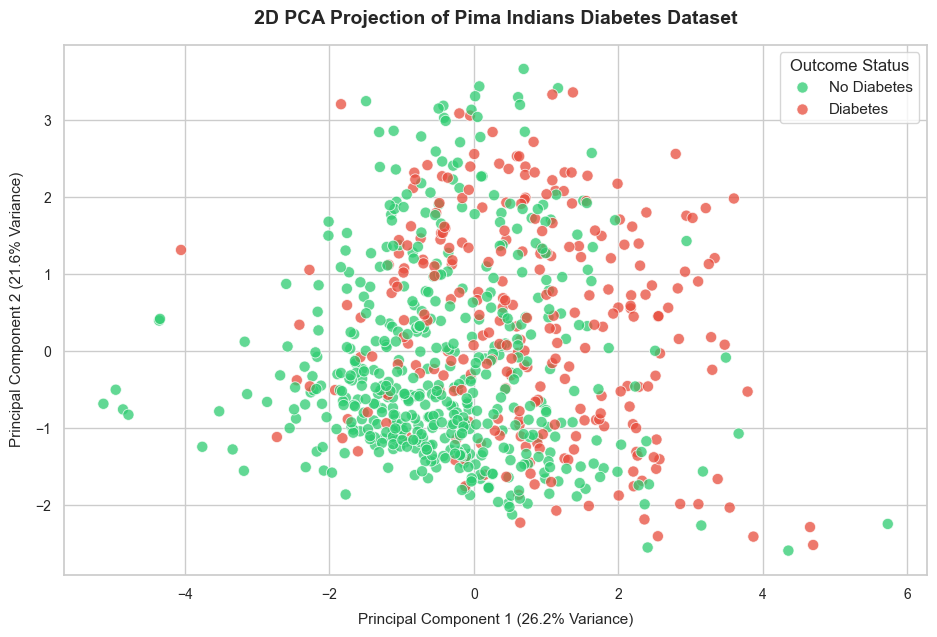

In [7]:
plt.figure(figsize=(9.5, 6.5))

# Scatter plot using Seaborn
scatter_plot = sns.scatterplot(
    x=X_projected_aligned[:, 0],
    y=X_projected_aligned[:, 1],
    hue=y,
    palette={0: '#2ecc71', 1: '#e74c3c'},  # Green and red
    alpha=0.75,
    edgecolor='w',
    s=65
)

plt.xlabel(f'Principal Component 1 ({evr[0]:.1%} Variance)', fontsize=11, labelpad=8)
plt.ylabel(f'Principal Component 2 ({evr[1]:.1%} Variance)', fontsize=11, labelpad=8)
plt.title('2D PCA Projection of Pima Indians Diabetes Dataset', fontsize=14, pad=15, weight='bold')

# Custom legend
handles, labels = scatter_plot.get_legend_handles_labels()
plt.legend(handles, ['No Diabetes', 'Diabetes'], title='Outcome Status', frameon=True, facecolor='w')

plt.tight_layout()
plt.show()

#### C. 3D Projection Scatter Plot
We project the data onto three principal components (PC1, PC2, and PC3) in a 3D scatter plot to observe if three dimensions provide a better separation between diagnostic categories.

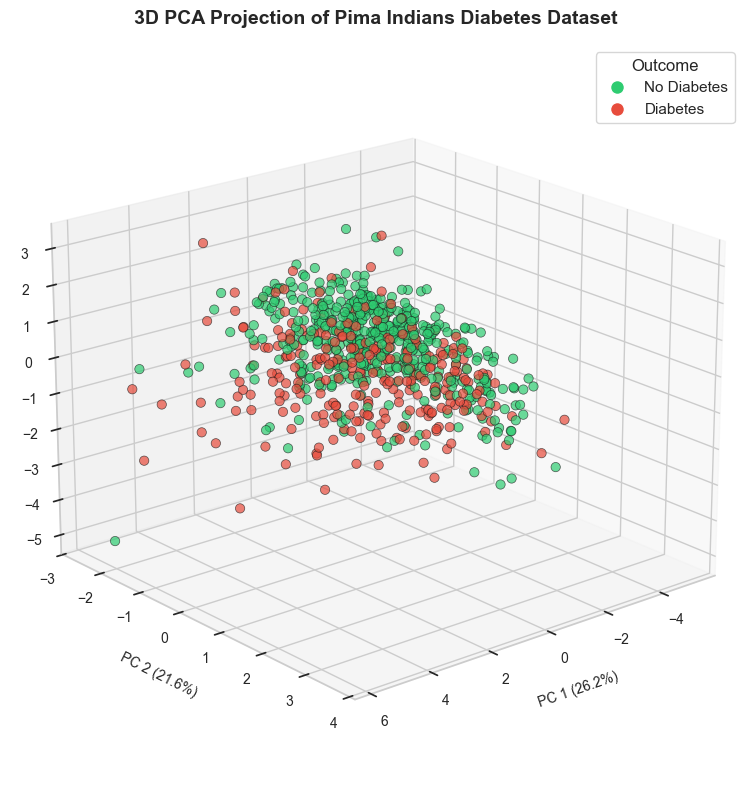

In [8]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# Color colors mapping outcome
colors = ['#2ecc71' if val == 0 else '#e74c3c' for val in y]

# Plot points in 3D
scatter = ax.scatter(
    X_projected_aligned[:, 0],
    X_projected_aligned[:, 1],
    X_projected_aligned[:, 2],
    c=colors,
    edgecolors='k',
    linewidths=0.5,
    s=45,
    alpha=0.7
)

# Label axes
ax.set_xlabel(f'PC 1 ({evr[0]:.1%})', fontsize=10, labelpad=10)
ax.set_ylabel(f'PC 2 ({evr[1]:.1%})', fontsize=10, labelpad=10)
ax.set_zlabel(f'PC 3 ({evr[2]:.1%})', fontsize=10, labelpad=10)

plt.title('3D PCA Projection of Pima Indians Diabetes Dataset', fontsize=14, pad=15, weight='bold')

# Custom legend creation since 3D scatter doesn't support hue mapping directly
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='No Diabetes'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Diabetes')
]
ax.legend(handles=legend_elements, title="Outcome", loc='upper right')

# Optimize view angle
ax.view_init(elev=20, azim=50)

plt.tight_layout()
plt.show()

#### D. PCA Biplot
A biplot displays both the projected coordinates (samples) and the variables' loadings (features) on the same plot. The arrows show the direction and strength of each feature's contribution to the first two principal components.

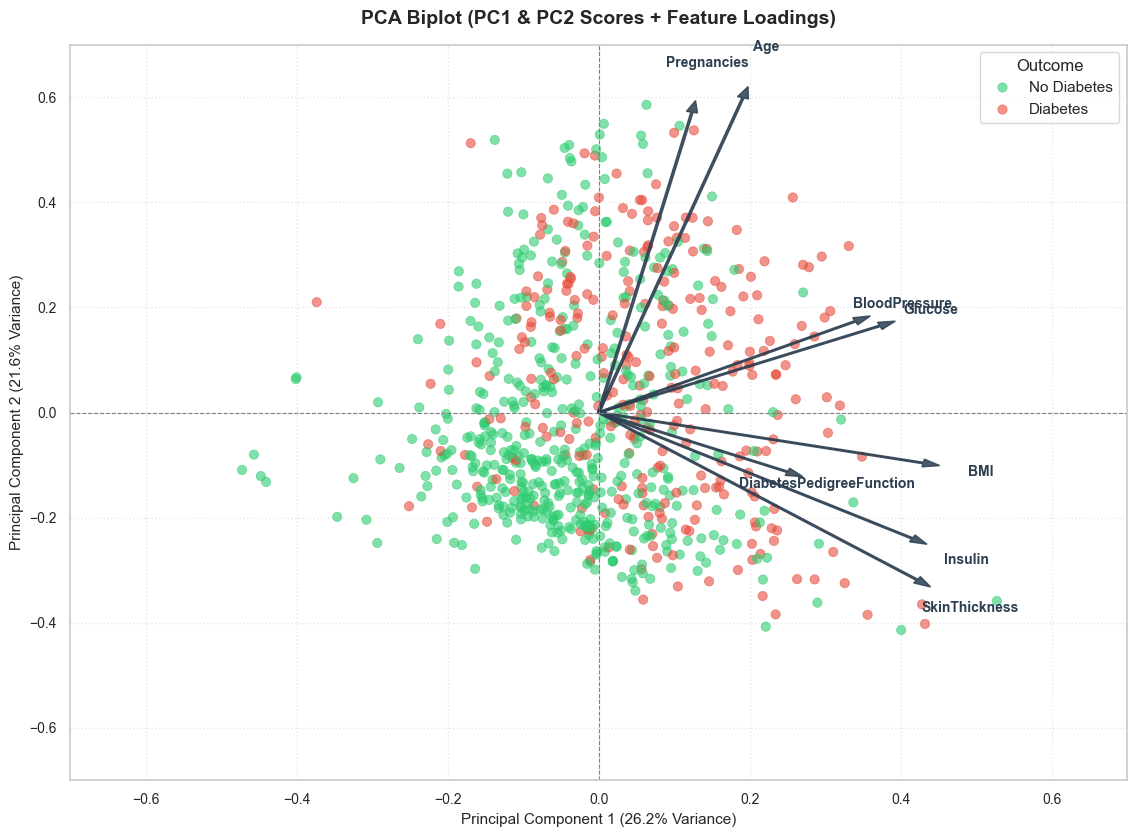

In [9]:
def draw_biplot(scores, loadings, feature_names, ev_ratio):
    plt.figure(figsize=(11.5, 8.5))
    
    # Scale scores coordinates to [ -1, 1 ] to overlap loadings arrows visually
    xs = scores[:, 0]
    ys = scores[:, 1]
    scale_x = 1.0 / (xs.max() - xs.min())
    scale_y = 1.0 / (ys.max() - ys.min())
    
    # Plot samples
    sns.scatterplot(
        x=xs * scale_x,
        y=ys * scale_y,
        hue=y,
        palette={0: '#2ecc71', 1: '#e74c3c'},
        alpha=0.6,
        s=45,
        edgecolor=None
    )
    
    # Plot feature loadings arrows
    for i, feature in enumerate(feature_names):
        dx = loadings[i, 0]
        dy = loadings[i, 1]
        
        # Draw direction arrow
        plt.arrow(0, 0, dx, dy, color='#2c3e50', alpha=0.85, width=0.003, 
                  head_width=0.015, length_includes_head=True)
        
        # Write feature label near arrow head
        plt.text(dx * 1.12, dy * 1.12, feature, color='#2c3e50', 
                 ha='center', va='center', weight='bold', fontsize=10)
        
    plt.xlim(-0.7, 0.7)
    plt.ylim(-0.7, 0.7)
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    
    plt.xlabel(f'Principal Component 1 ({ev_ratio[0]:.1%} Variance)', fontsize=11)
    plt.ylabel(f'Principal Component 2 ({ev_ratio[1]:.1%} Variance)', fontsize=11)
    plt.title('PCA Biplot (PC1 & PC2 Scores + Feature Loadings)', fontsize=14, pad=15, weight='bold')
    
    # Legend
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['No Diabetes', 'Diabetes'], title='Outcome', frameon=True)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Draw the biplot using aligned loadings (which represent feature weights)
# Note: The loadings matrix is the transpose of components_aligned
draw_biplot(X_projected_aligned, components_aligned.T, list(X.columns), evr)

#### E. Feature Loadings Heatmap
The loadings heatmap shows the exact weight (loading) of each original feature in the top three principal components. This visualization directly explains the physical meaning of the components.

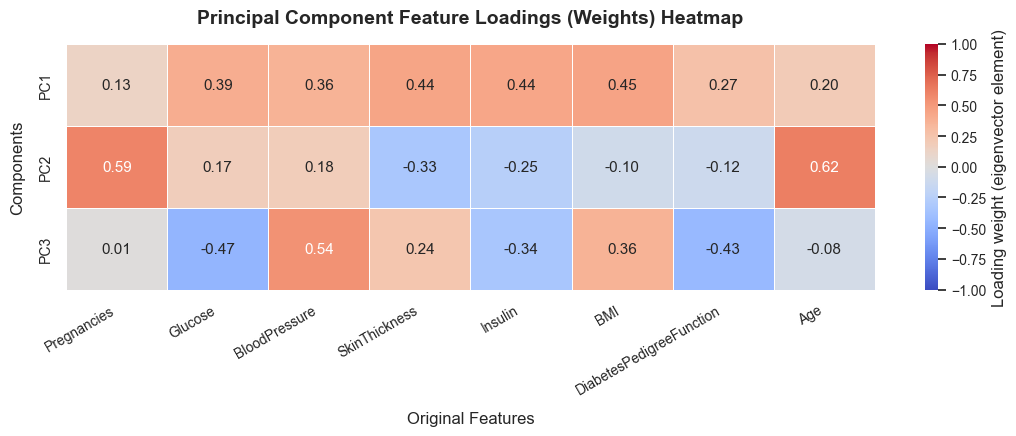

In [10]:
plt.figure(figsize=(11, 4.5))

# Create dataframe of aligned loadings
loadings_df = pd.DataFrame(
    components_aligned,
    columns=X.columns,
    index=['PC1', 'PC2', 'PC3']
)

# Plot using Seaborn heatmap
sns.heatmap(
    loadings_df,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.6,
    vmin=-1.0, vmax=1.0,
    cbar_kws={'label': 'Loading weight (eigenvector element)'}
)

plt.title('Principal Component Feature Loadings (Weights) Heatmap', pad=15, fontsize=14, weight='bold')
plt.xlabel('Original Features', labelpad=10)
plt.ylabel('Components', labelpad=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 7. Key Findings and Insights

1. **Explained Variance (Scree Plot)**: The first two principal components explain about **47.8%** of the total variance in the data, while the first three explain about **60.7%**. This means we can compress the 8 original variables into 3 dimensions while retaining the majority of feature information.
2. **Feature Associations (Biplot & Heatmap)**:
   - **PC1** has strong positive loadings from `BMI`, `SkinThickness`, `Glucose`, and `Pregnancies`. This can be interpreted as a component tracking **overall metabolic body mass and glucose output**.
   - **PC2** is heavily dominated by `Age` and `Pregnancies` (positive correlation) and negatively correlated with `Insulin`. This represents **demographic/age factors versus pancreatic responsiveness**.
3. **Separability (2D & 3D Projections)**: We can see a clear trend in both projection plots, where patients with a diabetes outcome (red points) tend to cluster towards the positive side of PC1, indicating that higher PC1 values (which correspond to higher BMI, Glucose, and Age) are strong clinical risk indicators.